In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint
import functools

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=2, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm
import torch

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
alt_ids = {
    # Lorenz96Bao2024EnSF
    # ('xa208i7f', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=97616566
    # ('1qn9szxd', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=97616566
    # ('4i1a0pl8', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=97616566
    # ('fkvx4o5c', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=97616566
    # ('xmcmiyi7', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=97616566
    # ('pmfi6ym4', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=97616566
    # ('r7fzmhkq', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=97616566
    # ('pmm3n20k', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=97616566
    # ('2tyw9dwl', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=97616566
    # ('bleyydx2', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=97616566
    # ('40wspp2g', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=97616566
    # ('hiboe685', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=97616566
    # ('09g3bhx3', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=97616566
    # ('2sjmg4k0', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=97616566
    # ('v212nww1', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=462133975
    # ('xscr0ykp', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=462133975
    # ('xp29tge5', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=462133975
    # ('uha1a304', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=462133975
    # ('dexfbenv', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=462133975
    # ('9fastxa9', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=462133975
    # ('nqbpry75', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=462133975
    # ('q3lihp2g', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=462133975
    # ('ysje1rns', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=462133975
    # ('s7gri7ib', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=462133975
    # ('nnu483ju', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=462133975
    # ('9vy21d00', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=462133975
    # ('45b1xyvo', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=462133975
    # ('ssdkiau3', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=462133975
    # ('5yrx2tf4', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=715319214
    # ('q55dmt6l', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=715319214
    # ('h5n1cp3a', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=715319214
    # ('f59k80a7', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=715319214
    # ('2c8sncpb', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=715319214
    # ('pnqbnqi3', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=715319214
    # ('ymhmzh5x', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=715319214
    # ('jxbmfcx5', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=715319214
    # ('k94iistq', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=715319214
    # ('bwj771gg', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=715319214
    # ('rysky1ei', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=715319214
    # ('6kr71f89', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=715319214
    # ('jemqhmvn', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=715319214
    # ('vy2lx5j3', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=715319214
    # ('3oite35n', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=979497033
    # ('tkmdibw2', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=979497033
    # ('om8ootqs', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=979497033
    # ('my1v8emg', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=979497033
    # ('z9q5cqtr', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=979497033
    # ('3q06228f', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=979497033
    # ('31dpe6np', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=979497033
    # ('ltbpotbf', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=979497033
    # ('va9z0nkc', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=979497033
    # ('ajzceffi', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=979497033
    # ('b4162cth', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=979497033
    # ('kg7vph6f', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=979497033
    # ('n5jkfog9', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=979497033
    # ('dxcb1lmk', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=979497033
    # ('ekcw5c3k', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=2376999025
    # ('cbc355m0', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=2376999025
    # ('eriikp1u', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
    # ('1xvp5lig', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
    # ('pkwvt6gk', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
    # ('7igtkq4a', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
    # ('yq1eaqxr', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
    # ('h8l7xw8q', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
    # ('f233y6lz', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=2376999025
    # ('ucdez2pm', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=2376999025
    # ('hnlt8l6r', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=2376999025
    # ('vocphl8c', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=2376999025
    # ('0guis8gf', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=2376999025
    # ('kjgcbtou', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=2376999025
    
    # NavierStokesDim64
    # ('1q0pimiw', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=97616566
    # ('uplja67a', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=97616566
    # ('u407tjbp', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=97616566
    # ('nu78wt7c', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=97616566
    # ('sfsy27vc', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=97616566
    # ('f9908g7m', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=97616566
    # ('2w2rwf0c', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=97616566
    # ('4f0eg86z', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=97616566
    # ('ktwei9t4', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=97616566
    # ('yighwqp3', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=97616566
    # ('6t0nr069', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=97616566
    # ('nzhw1kvt', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=97616566
    # ('idg1h58w', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=97616566
    # ('zm21jvfm', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=97616566
    # ('o09svyfe', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=462133975
    # ('g7jlru4c', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=462133975
    # ('05uz5egx', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=462133975
    # ('paf56gok', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=462133975
    # ('qgmlcthg', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=462133975
    # ('7vww91h3', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=462133975
    # ('p1nvic4f', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=462133975
    # ('fk708dzr', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=462133975
    # ('bisol1hi', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=462133975
    # ('h0gnfpv9', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=462133975
    # ('1b40jbyb', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=462133975
    # ('8vl64qe5', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=462133975
    # ('jg9egace', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=462133975
    # ('6gl8prb5', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=462133975
    # ('8qaorkqn', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=715319214
    # ('ovfmbzvy', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=715319214
    # ('lr4m9g3i', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=715319214
    # ('dwki10b2', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=715319214
    # ('pdcrol0s', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=715319214
    # ('dhg0w990', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=715319214
    # ('0mgoi1k6', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=715319214
    # ('daobe0dl', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=715319214
    # ('410ushi8', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=715319214
    # ('499uyoxr', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=715319214
    # ('dxbsczyh', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=715319214
    # ('6k9525hd', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=715319214
    # ('z0yhh7pr', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=715319214
    # ('z9wuixc1', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=715319214
    # ('1igrd88g', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=979497033
    # ('ahlrlbq0', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=979497033
    # ('ahez1o15', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=979497033
    # ('9uxkmt4e', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=979497033
    # ('0d280i72', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=979497033
    # ('w4tlx0pw', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=979497033
    # ('6oapd3dk', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=979497033
    # ('qj161jfx', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=979497033
    # ('wz1pdnzn', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=979497033
    # ('dszrxx33', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=979497033
    # ('iytdyrv2', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=979497033
    # ('gwwpox7r', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=979497033
    # ('pvu551ca', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=979497033
    # ('1hs2418q', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=979497033
    # ('ews5u7pv', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=2376999025
    # ('gncoj5bt', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=2376999025
    # ('if2agep8', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
    # ('cfbwxnup', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
    # ('c2f2fz7j', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
    # ('eijvq9xb', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
    # ('vpcuhvjp', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
    # ('fdyt2eb3', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
    # ('f35cpvjm', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=2376999025
    # ('8wulqyhl', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=2376999025
    # ('597z99o5', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=2376999025
    # ('6mpvp2wh', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=2376999025
    # ('1g1wnt91', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=2376999025
    # ('uj7177by', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=2376999025
    
    # NavierStokesDim256
    # ('b9njqbl3', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=97616566
    # ('st04uazn', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=97616566
    # ('cfkivxfw', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=97616566
    # ('u0akif41', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=97616566
    # ('4jkvp3sd', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=97616566
    # ('z4uy8jqu', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=97616566
    # ('y68jj7ko', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=97616566
    # ('bmqxrqdh', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=97616566
    # ('ysi1pcmv', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=97616566
    # ('3hf2n7qc', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=97616566
    # ('oqzvcu0z', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=97616566
    # ('65jo0gvo', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=97616566
    # ('io2qvta4', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=97616566
    # ('qgpwzjs4', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=97616566
    # ('n4ed0ahu', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=462133975
    # ('bjghrl4l', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=462133975
    # ('ghnu6unv', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=462133975
    # ('5srzjwrb', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=462133975
    # ('7y4lfs6c', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=462133975
    # ('9wgb8epw', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=462133975
    # ('3kjqc0x9', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=462133975
    # ('k426uvyz', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=462133975
    # ('oldaeinb', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=462133975
    # ('104rn5tf', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=462133975
    # ('k1dy40zi', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=462133975
    # ('n8kjdj42', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=462133975
    # ('5pn18bef', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=462133975
    # ('7u84gxjh', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=462133975
    # ('xyqimoi8', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=715319214
    # ('suawyw8f', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=715319214
    # ('9uodu1f9', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=715319214
    # ('xu2lmute', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=715319214
    # ('loddq8vu', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=715319214
    # ('u38vggmy', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=715319214
    # ('z19i455i', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=715319214
    # ('5561y8s3', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=715319214
    # ('yc5q95az', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=715319214
    # ('jygkacfh', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=715319214
    # ('m9bevl7a', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=715319214
    # ('c62a6axu', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=715319214
    # ('pc0h4d19', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=715319214
    # ('40gpfn30', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=715319214
    # ('7tsg6q49', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=979497033
    # ('ihc0mf9q', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=979497033
    # ('xaqbdstx', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=979497033
    # ('92rhnr4e', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=979497033
    # ('imfy6pzi', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=979497033
    # ('98lh1kty', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=979497033
    # ('weutcrns', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=979497033
    # ('8rk15k7z', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=979497033
    # ('iitftvid', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=979497033
    # ('c9zszooe', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=979497033
    # ('h3c47hu9', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=979497033
    # ('6fputjc4', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=979497033
    # ('a5muzqrm', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=979497033
    # ('zwilxtvb', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=979497033
    # ('knwi8dmh', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=2376999025
    # ('hjbzsbth', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=2376999025
    # ('08dypqnt', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
    # ('70e3he2q', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
    # ('in7i7zwn', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
    # ('x85htb7p', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
    # ('uoc15dkh', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
    # ('jerb4qqb', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
    # ('0d4ljpxi', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=2376999025
    # ('qemxjoa5', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=2376999025
    # ('a5gmmmf2', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=2376999025
    # ('sosmqxwg', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=2376999025
    # ('iofguvgt', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=2376999025
    # ('laolo8z4', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=2376999025
    
    # KuramotoSivashinsky
    # ('j2lb3707', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=97616566
    # ('kej81l5g', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=97616566
    # ('r0x03bpn', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=97616566
    # ('3k2gte7o', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=97616566
    # ('r6j7mz7t', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=97616566
    # ('dpay746j', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=97616566
    # ('1s790g5z', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=97616566
    # ('rsykevhy', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=97616566
    # ('3tmhvok5', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=97616566
    # ('nc0ma9ki', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=97616566
    # ('vas04naa', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=97616566
    # ('raqbzqht', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=97616566
    # ('53s478h1', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=97616566
    # ('t5viy2r4', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=97616566
    # ('wswrgwic', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=462133975
    # ('5rttbubs', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=462133975
    # ('la8cajc1', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=462133975
    # ('g671jhti', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=462133975
    # ('k8usyldj', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=462133975
    # ('as4tbkeo', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=462133975
    # ('h3rgu5rf', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=462133975
    # ('ktvdxqq6', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=462133975
    # ('yc7i6nwf', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=462133975
    # ('wv83fpz3', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=462133975
    # ('8pzg7p7g', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=462133975
    # ('zhl4yk00', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=462133975
    # ('m9o4g64z', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=462133975
    # ('kzz5xw48', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=462133975
    # ('q2xdek6s', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=715319214
    # ('3jz3gr2q', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=715319214
    # ('uevs40qo', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=715319214
    # ('mhvfqefv', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=715319214
    # ('71qimf5i', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=715319214
    # ('dsmyu7gu', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=715319214
    # ('4bcjvj74', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=715319214
    # ('b1x9phjs', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=715319214
    # ('5fvf1uk0', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=715319214
    # ('4ys5etvi', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=715319214
    # ('lf4xt4p3', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=715319214
    # ('5lkfvz0m', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=715319214
    # ('7kkdh0lb', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=715319214
    # ('fgut2gt1', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=715319214
    # ('s4hw7eta', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=979497033
    # ('9elk9pzt', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=979497033
    # ('g9d5c2af', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=979497033
    # ('6pd7d6zp', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=979497033
    # ('myod1mnu', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=979497033
    # ('lzm4recz', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=979497033
    # ('erilhzbx', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=979497033
    # ('e1bw0o3j', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=979497033
    # ('xmnmcsri', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=979497033
    # ('nl4eqdn9', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=979497033
    # ('dbai8wr6', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=979497033
    # ('ltnmb8qa', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=979497033
    # ('tqga1ux9', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=979497033
    # ('rcmee564', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=979497033
    # ('dgzxcxiz', 'EnFF'): {},  # sampling_time_step_count=5 rng_seed=2376999025
    # ('dpl9hpu3', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=2376999025
    # ('ic8igmlg', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
    # ('dwrinhfi', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
    # ('1h275uvu', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
    # ('glis0of9', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
    # ('wpp5ymyl', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
    # ('fje0w213', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
    # ('kfr14127', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=2376999025
    # ('juvk9m4i', 'EnFF'): {},  # sampling_time_step_count=100 rng_seed=2376999025
    # ('ep2zt2ko', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=2376999025
    # ('xybdysrj', 'EnFF'): {},  # sampling_time_step_count=200 rng_seed=2376999025
    # ('0gd7qcwu', 'EnFF'): {},  # sampling_time_step_count=500 rng_seed=2376999025
    # ('tbvlvdfa', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=2376999025
}

In [4]:
engine = conf.get_engine()
session = conf.sa.orm.Session(engine)
session.begin()

In [5]:
cfgs = session.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
cfgs = {c.alt_id: c for (c,) in cfgs}
cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
rng_seeds = []
cfg_dataset = None
for v in cfgs.values():
    cfg = v['cfg']
    if cfg_dataset is None:
        cfg_dataset = cfg.dataset
    assert isinstance(cfg.dataset, cfg_dataset.__class__)
    rng_seeds.append(cfg.rng_seed)
rng_seeds = np.array(rng_seeds)
assert (np.diff(rng_seeds) >= 0).all(), 'rng_seeds must be monotonically non-decreasing for dataset caching'

In [6]:
@functools.lru_cache(maxsize=1)
def get_true_state(cfg_dataset, rng_seed):
    lightning.pytorch.seed_everything(rng_seed)
    with lightning.pytorch.utilities.seed.isolate_rng():
        dynamics = datasets.get_dynamics_dataset(cfg_dataset, device=cfg.device)
    true_state = pl.DataFrame(
        torch.cat([dynamics.data['times'], dynamics.data['true_state'][:, 0]], dim=1).cpu().numpy(),
        schema=['times', *(f'true_state_dim_{d}' for d in range(dynamics.data['true_state'][:, 0].shape[1]))],
    )
    del dynamics
    if 'cuda' in cfg.device:
        torch.cuda.empty_cache()
    return true_state

In [7]:
for k, v in cfgs.items():
    cfg = v['cfg']
    print(cfg.alt_id)
    pl.scan_parquet(
        cfg.run_dir/cfg.prediction_filename,
    ).select(pl.col('times')).first().collect()

1q0pimiw


FileNotFoundError: No such file or directory (os error 2): /home/sci/ttransue/out/dafm/runs/1q0pimiw/trajectories.parquet

This error occurred with the following context stack:
	[1] 'parquet scan'
	[2] 'select'
	[3] 'slice'
	[4] 'sink'


In [ ]:
rmses = []
for k, v in tqdm(cfgs.items()):
    print(cfg.alt_id)
    cfg = v['cfg']

    true_state = get_true_state(cfg.dataset, cfg.rng_seed)
    
    rmse = (
        pl.scan_parquet(
            cfg.run_dir/cfg.prediction_filename,
        )
        # take last X time steps when data assimilation occurred
        .sort('times')
        .gather_every(cfg.dataset.observe_every_n_time_steps, offset=1)  # offset to exclude initial condition
        .tail(50)
        
        .join(true_state.lazy(), on='times')
        .select(
            pl.lit(k[0]).alias('alt_id'),
            pl.lit(k[1]).alias('label'),
            pl.lit(cfg.rng_seed, dtype=pl.datatypes.Int64).alias('rng_seed'),
            pl.col('times'),
            pl.lit(cfg.model.sampling_time_step_count).alias('Sampling timesteps'),
            pl.mean_horizontal(
                (
                    pl.col(f'predicted_state_mean_dim_{d}') - pl.col(f'true_state_dim_{d}')
                ).pow(2)
                for d in range(cfg.dataset.state_dimension)
            ).sqrt().alias('RMSE(dim)'),
        )
        .group_by('alt_id', 'label', 'rng_seed', 'Sampling timesteps')
        .agg(pl.col('RMSE(dim)').mean().alias('Mean(time) RMSE(dim)').alias('RMSE'))
        .collect()
    )
    print(rmse)
    rmses.append(rmse)
    
rmses = pl.concat(rmses)
rmses

In [ ]:
# rmses

In [ ]:
# table = (
#     rmses
#     .group_by('label', 'Sampling timesteps')
#     .agg(
#         pl.col('RMSE').mean().alias('RMSE mean'),
#         pl.col('RMSE').std(ddof=0).alias('RMSE std.'),
#     )
#     .select(
#         pl.format('{} ({})', pl.col('label'), pl.col('Sampling timesteps')).alias('Model'),
#         # (pl.col('label') + ' (' + pl.col('Sampling timesteps').cast(str) + ')').alias('Model'),
#         pl.format(
#             r'${}_{{\pm {}}}$',
#             pl.col('RMSE mean').map_elements(lambda x: f'{x:.2f}', return_dtype=str),
#             pl.col('RMSE std.').map_elements(lambda x: f'{x:.2f}', return_dtype=str),
#         ).alias('RMSE'),
#     )
# )
# table

In [ ]:
# print(table.to_pandas().to_latex(index=False))

In [ ]:
# rmses.write_parquet('rmses_Lorenz96Bao2024EnSF.parquet')

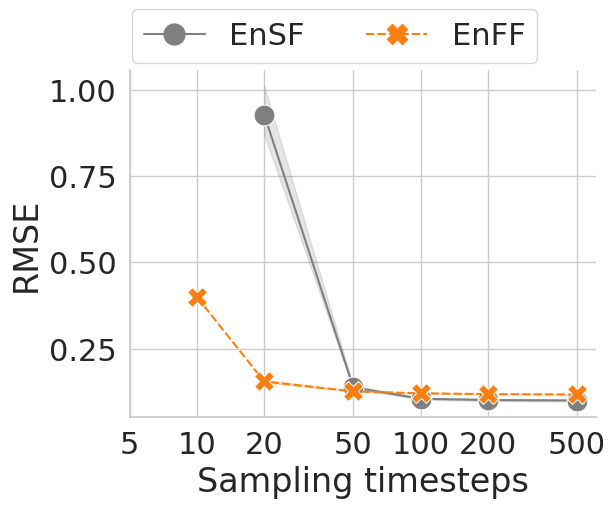

In [10]:
xticks = rmses.select(pl.col('Sampling timesteps').unique()).to_numpy().squeeze()
# yticks = list(torch.linspace(.1, 15, 20).numpy())[::2]
plot_rmse = (
    sns.relplot(
        kind='line',
        data=rmses,
        x='Sampling timesteps',
        y='RMSE',
        hue='label',
        hue_order=['EnSF', 'EnFF'],
        style_order=['EnSF', 'EnFF'],
        style='label',
        palette={
            'EnSF': 'tab:gray',
            'EnFF': 'tab:orange',
        },
        errorbar=('pi', 100),
        markers=True,
        markersize=15,
        linewidth=1.5,
        aspect=1.3,
    )
    .set(
        # ylim=(0, 1),
        xscale='log',
        # yscale='log',
        xticks=xticks,
        xticklabels=xticks,
        # yticks=yticks,
        # yticklabels=yticks,
    )
)
# ax_twin = plot_rmse.axes[0][0].twinx()
# ax_twin.set_axis_off()
sns.move_legend(
    plot_rmse,
    loc='upper center',
    ncol=min(len(alt_ids), 2) + 1,
    title='',
    bbox_to_anchor=(.455, 1.08),
    frameon=True,
    fancybox=True,
)

In [11]:
plots.save_all_subfigures(plot_rmse, 'RMSE')